In [39]:
import pandas as pd
import numpy as np


In [71]:
data=pd.read_csv('/content/netflix_data.csv')
data
new_data=data.copy()

In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [42]:
data.isnull().sum()


,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [43]:
data.fillna('',inplace=True)

In [44]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8807,8807,s8807,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8807,2,Movie,6131,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8807,8807,Zubaan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,8807,4529,,2634,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cast,8807,7693,,825,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8807,749,United States,2818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8807,1768,"January 1, 2020",109,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8807.0,NaN,NaN,NaN,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8807,18,TV-MA,3207,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8807,221,1 Season,1793,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
movie_counts=data['release_year'].value_counts().sort_index()
movie_counts

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


In [46]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
fig=go.Figure(data=go.Bar(x=movie_counts.index,y=movie_counts.values))
fig.update_layout(
    font_color='red',
    title='Number of movies released each year',
    xaxis=dict(title='Year'),
    yaxis=dict(title='Number of movies')
)
fig.update_traces(marker_color='red')
fig.show()

In [47]:
movietc=data['type'].value_counts()
fig=go.Figure(data=go.Pie(labels=movietc.index,values=movietc.values))
fig.update_layout(
    font_color='red',
    title='Number of Movies and TV Shows'
)
fig.show()

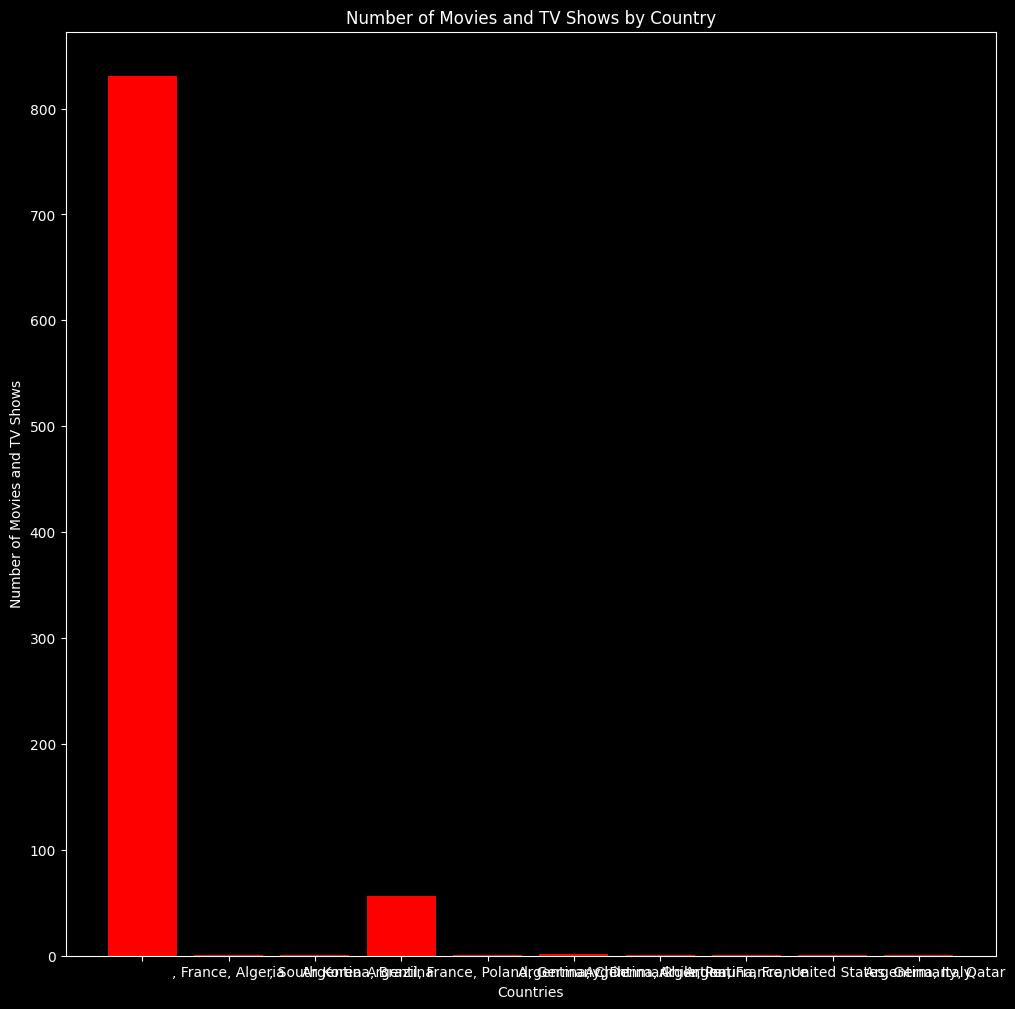

In [48]:
moviecountry=data['country'].value_counts().sort_index()
top_countries=moviecountry.head(10)
plt.figure(figsize=(12,12))
plt.bar(top_countries.index,top_countries.values,color='red')
plt.title('Number of Movies and TV Shows by Country')
plt.xlabel('Countries')
plt.ylabel('Number of Movies and TV Shows')
plt.style.use('dark_background')
plt.show()



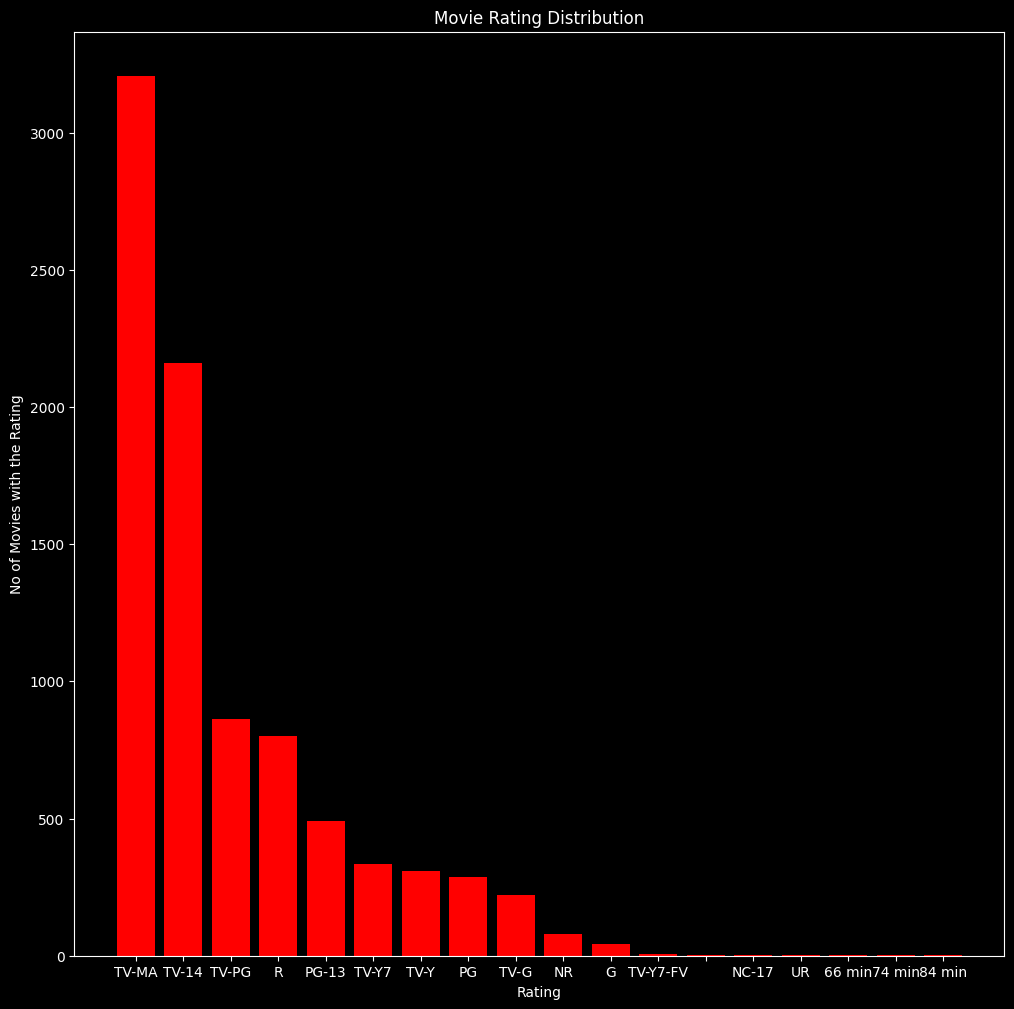

In [49]:
movierating=data['rating'].value_counts()
movierating
plt.figure(figsize=(12,12))
plt.bar(movierating.index,movierating.values,color='red')
plt.title('Movie Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('No of Movies with the Rating')
plt.show()

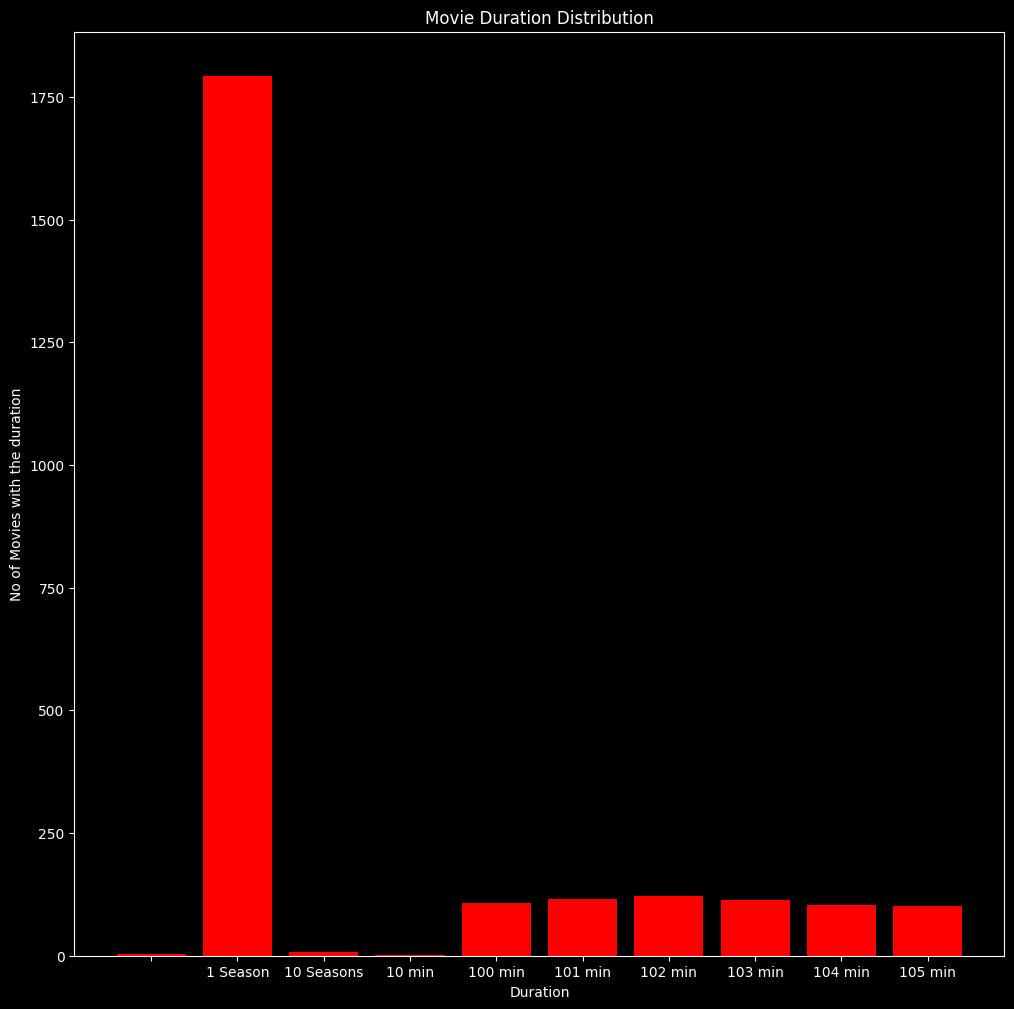

In [50]:
movieduration=data['duration'].value_counts().sort_index()
movietop=movieduration.head(10)
plt.figure(figsize=(12,12))
plt.bar(movietop.index,movietop.values,color='red')
plt.title('Movie Duration Distribution')
plt.xlabel('Duration')
plt.ylabel('No of Movies with the duration')
plt.show()

In [51]:
data.columns
data=data.drop(columns=['show_id','country','date_added','release_year','duration'])
data.set_index('title',inplace=True)

In [52]:
data.head()

,type,director,cast,rating,listed_in,description
title,,,,,,
Dick Johnson Is Dead,Movie,Kirsten Johnson,,PG-13,Documentaries,"As her father nears the end of his life, filmm..."
Blood & Water,TV Show,,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",TV-MA,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
Ganglands,TV Show,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",TV-MA,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
Jailbirds New Orleans,TV Show,,,TV-MA,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
Kota Factory,TV Show,,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",TV-MA,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [53]:
# from sklearn.preprocessing import FunctionTransformer
import string
# def seperate_text(texts):
#   return texts.apply(
#       lambda texts:''.join(set(
#           t.strip().lower()
#           for t in str(text).split(',')
#       ))
#   )
# def remove_spaces(texts):
#   return texts.apply(
#       lambda texts:str(texts).replace(' ','').lower()

#   )
# def remove_punc(texts):
#   return texts.apply(
#       lambda texts:' '.join(
#           str(text)
#           .lower()
#           .translate(str.maketrans(",",string.punctuation))
#           .split()
#       )
#   )
# def clea_text(texts):
#   texts=self.seperate_text(texts)
#   texts=self.remove_spaces(texts)
#   texts=self.remove_punc(texts)
#   return texts
# space_trans=FunctionTransformer(remove_spaces)
# sep_trans=FunctionTransformer(seperate_text)
# punc_trans=FunctionTransformer(remove_punc)



In [54]:
# remspace=[0,4]
# septext=[2,3,5]
# rempunc=[6]
# from sklearn.compose import make_column_transformer
# trans=make_column_transformer((space_trans,remspace),(sep_trans,septext),(punc_trans,punc_trans),remainder='passthrough')
# trans

In [55]:
class TextCleaner:
    def separate_text(self, texts):
        unique_texts = set()
        for text in texts.split(','):
            unique_texts.add(text.strip().lower())
        return ' '.join(unique_texts)

    def remove_space(self, texts):
        return texts.replace(' ', '').lower()

    def remove_punc(self, texts):
        texts = texts.lower()
        texts = texts.translate(str.maketrans('', '', string.punctuation))
        return ' '.join(texts.split())

    def clean_text(self, texts):
        texts = self.separate_text(texts)
        texts = self.remove_space(texts)
        texts = self.remove_punc(texts)
        return texts

In [56]:
cleaner = TextCleaner()


In [57]:
data['type']        = data['type'].apply(cleaner.remove_space)
data['director']    = data['director'].apply(cleaner.separate_text)
data['cast']        = data['cast'].apply(cleaner.separate_text)
data['rating']      = data['rating'].apply(cleaner.remove_space)
data['listed_in']   = data['listed_in'].apply(cleaner.separate_text)
data['description'] = data['description'].apply(cleaner.remove_punc)

In [58]:
data.head()

,type,director,cast,rating,listed_in,description
title,,,,,,
Dick Johnson Is Dead,movie,kirsten johnson,,pg-13,documentaries,as her father nears the end of his life filmma...
Blood & Water,tvshow,,ama qamata ryle de morny thabang molaba dillon...,tv-ma,tv dramas tv mysteries international tv shows,after crossing paths at a party a cape town te...
Ganglands,tvshow,julien leclercq,sami bouajila noureddine farihi tracy gotoas s...,tv-ma,crime tv shows tv action & adventure internati...,to protect his family from a powerful drug lor...
Jailbirds New Orleans,tvshow,,,tv-ma,reality tv docuseries,feuds flirtations and toilet talk go down amon...
Kota Factory,tvshow,,jitendra kumar arun kumar ahsaas channa revath...,tv-ma,tv comedies romantic tv shows international tv...,in a city of coaching centers known to train i...


In [59]:
data['bow']=data.apply(lambda row:' '.join(row.dropna().values),axis=1)
data.drop(data.columns[:-1],axis=1,inplace=True)
data

,bow
title,
Dick Johnson Is Dead,movie kirsten johnson pg-13 documentaries as ...
Blood & Water,tvshow ama qamata ryle de morny thabang molab...
Ganglands,tvshow julien leclercq sami bouajila noureddin...
Jailbirds New Orleans,tvshow tv-ma reality tv docuseries feuds fli...
Kota Factory,tvshow jitendra kumar arun kumar ahsaas chann...
...,...
Zodiac,movie david fincher robert downey jr. elias ko...
Zombie Dumb,tvshow tv-y7 kids' tv tv comedies korean tv ...
Zombieland,movie ruben fleischer emma stone derek graf am...


In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfid=TfidfVectorizer()
tfid_matrix=tfid.fit_transform(data['bow'])
tfid_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 381860 stored elements and shape (8807, 52053)>

In [65]:
from sklearn.metrics.pairwise import cosine_similarity
cosine_sim=cosine_similarity(tfid_matrix,tfid_matrix)
cosine_sim

array([[1.        , 0.00504833, 0.02011193, ..., 0.01065369, 0.02109898,
        0.03048859],
       [0.00504833, 1.        , 0.01714561, ..., 0.00103121, 0.        ,
        0.00481712],
       [0.02011193, 0.01714561, 1.        , ..., 0.00560911, 0.01042642,
        0.0333502 ],
       ...,
       [0.01065369, 0.00103121, 0.00560911, ..., 1.        , 0.05649084,
        0.00600011],
       [0.02109898, 0.        , 0.01042642, ..., 0.05649084, 1.        ,
        0.01046521],
       [0.03048859, 0.00481712, 0.0333502 , ..., 0.00600011, 0.01046521,
        1.        ]])

In [66]:
np.save('tfid_matrix.npy',tfid_matrix)
np.save('cosine_sim.npy',cosine_sim)


In [69]:
import pickle
with open('tfidf_vectorizer.pkl','wb') as f:
  pickle.dump(tfid,f)

In [73]:
final_data=new_data[['title','type']]
final_data

,title,type
0,Dick Johnson Is Dead,Movie
1,Blood & Water,TV Show
2,Ganglands,TV Show
3,Jailbirds New Orleans,TV Show
4,Kota Factory,TV Show
...,...,...
8802,Zodiac,Movie
8803,Zombie Dumb,TV Show
8804,Zombieland,Movie
8805,Zoom,Movie


In [87]:
from scipy.sparse import save_npz
import warnings
warnings.filterwarnings('ignore')
import re
class Suggestit:
    def __init__(self, df, cosine_sim):
        self.df = df
        self.cosine_sim = cosine_sim
    def recommendation(self, title, total_result=5, threshold=0.5):

        idx = self.find_id(title)

        self.df['similarity'] = self.cosine_sim[idx]

        sort_df = self.df.sort_values(
            by='similarity',
            ascending=False
        )[1:total_result+1]
        movies = sort_df['title'][sort_df['type'] == 'Movie']
        tv_shows = sort_df['title'][sort_df['type'] == 'TV Show']
        similar_movies = []
        similar_tv_shows = []
        for i, movie in enumerate(movies):
            similar_movies.append('{}. {}'.format(i+1, movie))
        for i, tv_show in enumerate(tv_shows):
            similar_tv_shows.append('{}. {}'.format(i+1, tv_show))
        return similar_movies, similar_tv_shows
    def find_id(self, name):
        for index, string in enumerate(self.df['title']):
            if isinstance(string, str) and re.search(name, string):
                return index
        return -1


In [89]:
suggest=Suggestit(final_data,cosine_sim)
movies, tv_shows=suggest.recommendation('Annabelle',total_result=10,threshold=0.5)
print('Similar Movies list:')
for movie in movies:
  print(movie)
print('Similar TV Shows')
for tv_show in tv_shows:
  print(tv_show)

Similar Movies list:
1. God Bless the Broken Road
2. R.L. Stine's Mostly Ghostly
3. A Week Away
4. Secrets of Highclere Castle
5. Whitney Cummings: Can I Touch It?
6. The Ugly Truth
7. Whitney Cummings: Money Shot
8. Secrets of the Tower of London
9. Alarmoty in the Land of Fire
10. The Resurrection of Gavin Stone
Similar TV Shows
